<a href="https://colab.research.google.com/github/KBSanchai/crop-insect-classifier/blob/main/MinorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow torch torchvision matplotlib scikit-learn seaborn tqdm -q

import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only — switch to T4!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.1 MB/s eta 0:00:00
GPU available: False
Device: CPU only — switch to T4!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from roboflow import Roboflow

rf = Roboflow(api_key="qsoY2Xn003BKLD8IZ1y4")   # replace with your key

project1 = rf.workspace("drivermonitoringsystem-qcq2d").project("insect-pesticide")
dataset1 = project1.version(1).download("folder")

project2 = rf.workspace("drivermonitoringsystem-qcq2d").project("fertilizer-sprinkling")
dataset2 = project2.version(2).download("folder")

print("\nInsect path    :", dataset1.location)
print("Fertilizer path:", dataset2.location)

Mounted at /content/drive
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Insect-Pesticide-1 in folder:: 100%|██████████| 726/726 [00:00<00:00, 2273.23it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to Fertilizer-Sprinkling-2 in folder:: 100%|██████████| 8281/8281 [00:07<00:00, 1052.99it/s]


Insect path    : /content/Insect-Pesticide-1
Fertilizer path: /content/Fertilizer-Sprinkling-2


In [ ]:
import os, shutil, pandas as pd

# ── Step A: Diagnose ──
for name, path in [("Insect",     dataset1.location),
                   ("Fertilizer", dataset2.location)]:
    print(f"\n{'='*45}\n  {name}\n{'='*45}")
    for split in ["train", "valid", "test"]:
        sp = f"{path}/{split}"
        if not os.path.exists(sp):
            print(f"  {split}: NOT FOUND"); continue
        items = os.listdir(sp)
        print(f"\n  {split}/  →  {items}")
        for item in items:
            fp = f"{sp}/{item}"
            if os.path.isdir(fp):
                imgs = [f for f in os.listdir(fp)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                print(f"    {item}/  →  {len(imgs)} images")
            else:
                print(f"    {item}  ← FILE")

# ── Step B: Fix if images are flat with _classes.csv ──
def fix_flat_to_folders(base_dir):
    for split in ["train", "valid", "test"]:
        sp       = f"{base_dir}/{split}"
        csv_path = f"{sp}/_classes.csv"
        if not os.path.exists(csv_path):
            print(f"  {split}: already in folder format — OK")
            continue
        print(f"\n  Fixing {split}/...")
        df           = pd.read_csv(csv_path)
        filename_col = df.columns[0]
        class_cols   = df.columns[1:]
        moved = 0
        for _, row in df.iterrows():
            fname = str(row[filename_col]).strip()
            src   = f"{sp}/{fname}"
            if not os.path.exists(src):
                continue
            primary = None
            for col in class_cols:
                if str(row[col]).strip() in ['1','1.0','True','true']:
                    primary = col.strip(); break
            if primary is None:
                primary = "unknown"
            dst = f"{sp}/{primary}"
            os.makedirs(dst, exist_ok=True)
            shutil.move(src, f"{dst}/{fname}")
            moved += 1
        print(f"  Moved {moved} images into class folders")
        for d in os.listdir(sp):
            if os.path.isdir(f"{sp}/{d}"):
                n = len(os.listdir(f"{sp}/{d}"))
                print(f"    {d}/  →  {n} images")

print("\n\nFixing Insect dataset...")
fix_flat_to_folders(dataset1.location)

print("\n\nFixing Fertilizer dataset...")
fix_flat_to_folders(dataset2.location)


  Insect

  train/  →  ['rice bug', 'Rice stem borer', 'planthopper', 'green leafhopper', 'rice leaf roller']
    rice bug/  →  204 images
    Rice stem borer/  →  147 images
    planthopper/  →  33 images
    green leafhopper/  →  75 images
    rice leaf roller/  →  159 images

  valid/  →  ['rice bug', 'Rice stem borer', 'planthopper', 'green leafhopper', 'rice leaf roller']
    rice bug/  →  19 images
    Rice stem borer/  →  14 images
    planthopper/  →  3 images
    green leafhopper/  →  7 images
    rice leaf roller/  →  15 images

  test/  →  ['rice bug', 'Rice stem borer', 'planthopper', 'green leafhopper', 'rice leaf roller']
    rice bug/  →  10 images
    Rice stem borer/  →  7 images
    planthopper/  →  2 images
    green leafhopper/  →  3 images
    rice leaf roller/  →  8 images

  Fertilizer

  train/  →  ['Healthy Crop NeckBlast', 'Blast Disease Brown Spot Disease', 'Bacterial Blight Disease', 'Unlabeled', 'Bacterial Blight Disease Blast Disease', 'Healthy Crop', 'Bl

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE   = 224
BATCH_SIZE = 32

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def build_loaders(base_dir):
    train_ds = ImageFolder(f"{base_dir}/train", transform=transform_train)
    valid_ds = ImageFolder(f"{base_dir}/valid", transform=transform_eval)
    test_ds  = ImageFolder(f"{base_dir}/test",  transform=transform_eval)
    trl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vll = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    tel = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f"\n{os.path.basename(base_dir)}")
    print(f"  Classes ({len(train_ds.classes)}): {train_ds.classes}")
    print(f"  Train {len(train_ds)} | Valid {len(valid_ds)} | Test {len(test_ds)}")
    return trl, vll, tel, train_ds.classes

train_loader1, valid_loader1, test_loader1, classes1 = build_loaders(dataset1.location)
train_loader2, valid_loader2, test_loader2, classes2 = build_loaders(dataset2.location)


Insect-Pesticide-1
  Classes (5): ['Rice stem borer', 'green leafhopper', 'planthopper', 'rice bug', 'rice leaf roller']
  Train 618 | Valid 58 | Test 30

Fertilizer-Sprinkling-2
  Classes (10): ['Bacterial Blight Disease', 'Bacterial Blight Disease Blast Disease', 'Blast Disease', 'Blast Disease Brown Spot Disease', 'Brown Spot Disease', 'False Smut Disease', 'Healthy Crop', 'Healthy Crop NeckBlast', 'NeckBlast', 'Unlabeled']
  Train 6971 | Valid 855 | Test 428


In [ ]:
import torch.nn as nn
import torchvision.models as models

def build_resnet18(num_classes):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in m.parameters():
        param.requires_grad = False
    for param in m.layer4.parameters():
        param.requires_grad = True
    m.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(m.fc.in_features, num_classes)
    )
    return m.to(device)

model1 = build_resnet18(len(classes1))
model2 = build_resnet18(len(classes2))

trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")
print(f"model1 → {len(classes1)} classes: {classes1}")
print(f"model2 → {len(classes2)} classes: {classes2}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 65.5MB/s]


Trainable params: 8,396,293
model1 → 5 classes: ['Rice stem borer', 'green leafhopper', 'planthopper', 'rice bug', 'rice leaf roller']
model2 → 10 classes: ['Bacterial Blight Disease', 'Bacterial Blight Disease Blast Disease', 'Blast Disease', 'Blast Disease Brown Spot Disease', 'Brown Spot Disease', 'False Smut Disease', 'Healthy Crop', 'Healthy Crop NeckBlast', 'NeckBlast', 'Unlabeled']


In [ ]:
import torch.optim as optim
from tqdm import tqdm

def train_model(model, train_loader, valid_loader,
                num_epochs, save_path, label):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_losses, val_losses, val_accs = [], [], []
    best_acc = 0.0

    for epoch in range(num_epochs):
        # ── Train ──
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader,
                                   desc=f"[{label}] Epoch {epoch+1}/{num_epochs}",
                                   leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train = running_loss / len(train_loader)
        train_losses.append(avg_train)

        # ── Validate ──
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                out     = model(images)
                val_loss += criterion(out, labels).item()
                _, pred  = torch.max(out, 1)
                correct += (pred == labels).sum().item()
                total   += labels.size(0)

        avg_val = val_loss / len(valid_loader)
        acc     = 100.0 * correct / total
        val_losses.append(avg_val)
        val_accs.append(acc)
        scheduler.step()

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), save_path)

        if (epoch + 1) % 5 == 0:
            print(f"[{label}] Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | Acc: {acc:.2f}%")

    print(f"\n[{label}] Best accuracy: {best_acc:.2f}%")
    return train_losses, val_losses, val_accs

print("="*50)
print("  Insect Pesticide 1")
print("="*50)
tl1, vl1, va1 = train_model(
    model1, train_loader1, valid_loader1,
    num_epochs=60,
    save_path="/content/insect_best.pth",
    label="Insect"
)

print("\n" + "="*50)
print("  Fertilizer Sprinkling 2")
print("="*50)
tl2, vl2, va2 = train_model(
    model2, train_loader2, valid_loader2,
    num_epochs=30,
    save_path="/content/fertilizer_best.pth",
    label="Fertilizer"
)

  Insect Pesticide 1


[Insect] Epoch   5/60 | Train: 0.0888 | Val: 0.8622 | Acc: 84.48%


[Insect] Epoch  10/60 | Train: 0.0540 | Val: 1.0994 | Acc: 82.76%


[Insect] Epoch  15/60 | Train: 0.0690 | Val: 1.0971 | Acc: 81.03%


[Insect] Epoch  20/60 | Train: 0.0295 | Val: 0.8870 | Acc: 84.48%


...

[Fertilizer] Epoch  10/30 | Train: 0.3659 | Val: 11.1978 | Acc: 6.20%


[Fertilizer] Epoch  15/30 | Train: 0.3037 | Val: 13.0830 | Acc: 5.96%


[Fertilizer] Epoch  20/30 | Train: 0.2389 | Val: 13.8949 | Acc: 3.98%


[Fertilizer] Epoch  25/30 | Train: 0.1834 | Val: 15.5433 | Acc: 4.44%


[Fertilizer] Epoch  30/30 | Train: 0.1711 | Val: 14.4440 | Acc: 4.80%

[Fertilizer] Best accuracy: 7.02%


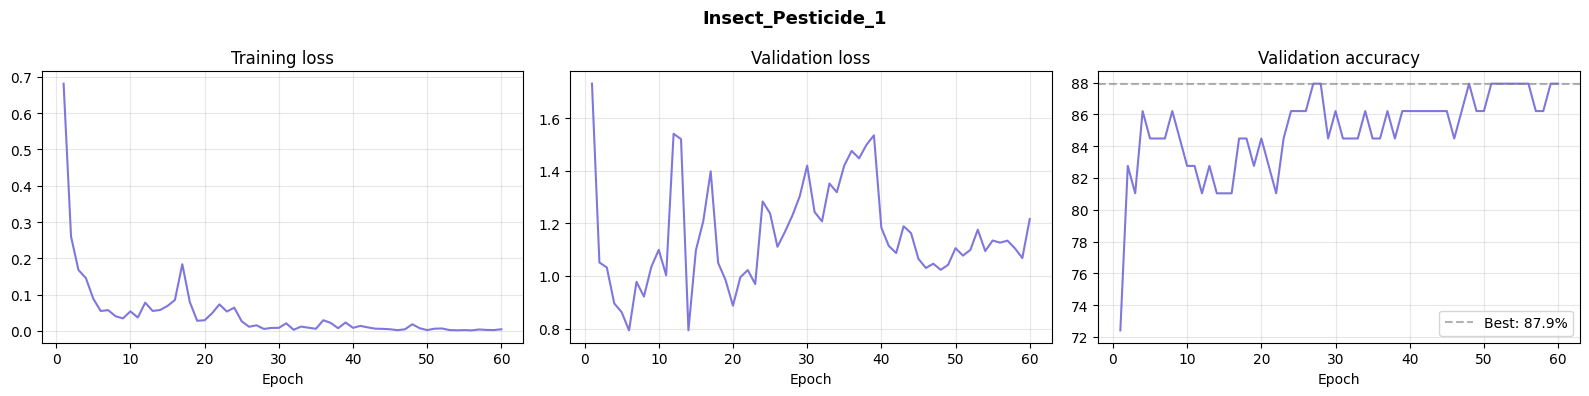

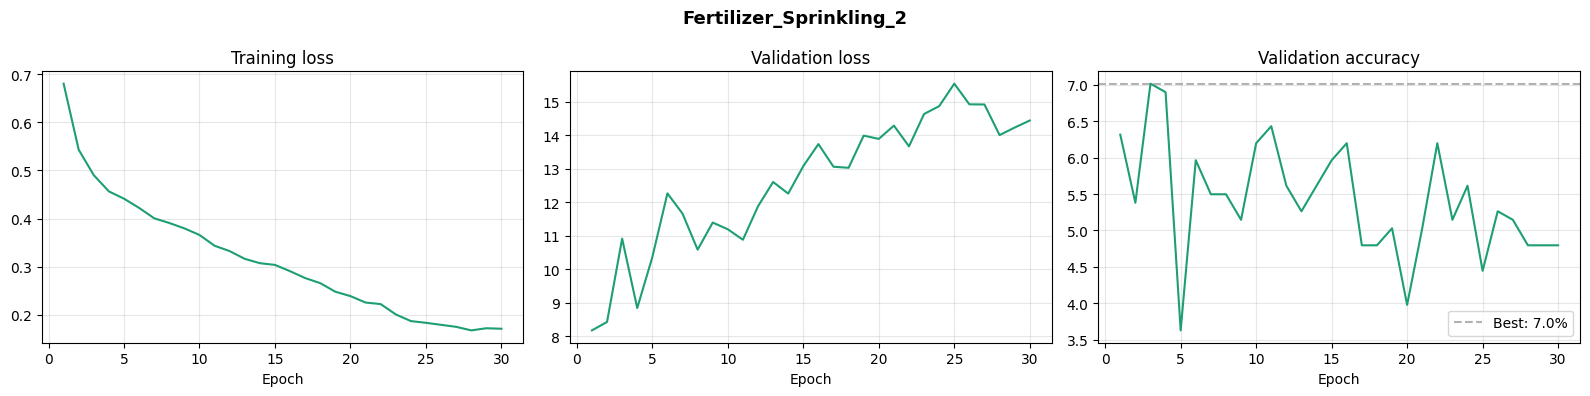

In [ ]:
import matplotlib.pyplot as plt

def plot_training(tl, vl, va, title, color):
    epochs = range(1, len(tl) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(epochs, tl, color=color, linewidth=1.5)
    axes[0].set_title("Training loss"); axes[0].set_xlabel("Epoch")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, vl, color=color, linewidth=1.5)
    axes[1].set_title("Validation loss"); axes[1].set_xlabel("Epoch")
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(epochs, va, color=color, linewidth=1.5)
    axes[2].axhline(max(va), linestyle='--', color='gray',
                    alpha=0.6, label=f"Best: {max(va):.1f}%")
    axes[2].set_title("Validation accuracy"); axes[2].set_xlabel("Epoch")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/content/{title}_training.png", dpi=150)
    plt.show()

plot_training(tl1, vl1, va1, "Insect_Pesticide_1",     "#7F77DD")
plot_training(tl2, vl2, va2, "Fertilizer_Sprinkling_2", "#1D9E75")

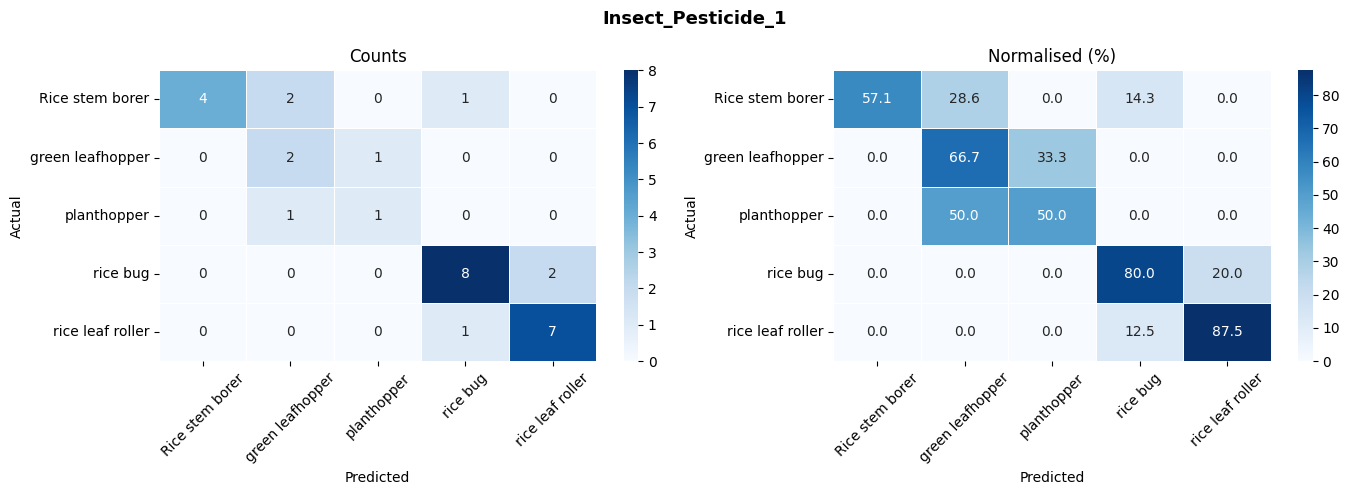

                  precision    recall  f1-score   support

 Rice stem borer       1.00      0.57      0.73         7
green leafhopper       0.40      0.67      0.50         3
     planthopper       0.50      0.50      0.50         2
        rice bug       0.80      0.80      0.80        10
rice leaf roller       0.78      0.88      0.82         8

        accuracy                           0.73        30
       macro avg       0.70      0.68      0.67        30
    weighted avg       0.78      0.73      0.74        30



invalid value encountered in divide


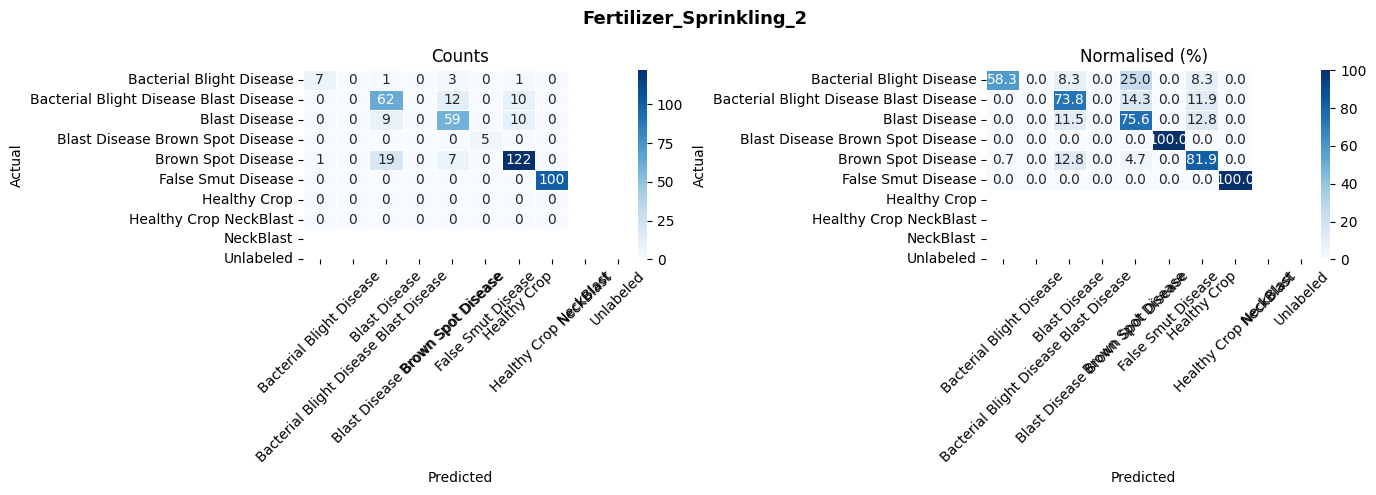

                                        precision    recall  f1-score   support

              Bacterial Blight Disease       0.88      0.58      0.70        12
Bacterial Blight Disease Blast Disease       0.00      0.00      0.00        84
                         Blast Disease       0.10      0.12      0.11        78
      Blast Disease Brown Spot Disease       0.00      0.00      0.00         5
                    Brown Spot Disease       0.09      0.05      0.06       149
                    False Smut Disease       0.00      0.00      0.00       100

                             micro avg       0.12      0.05      0.08       428
                             macro avg       0.18      0.12      0.14       428
                          weighted avg       0.07      0.05      0.06       428



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def plot_confusion_matrix(model, test_loader, class_names, save_path, title):
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            _, pred = torch.max(model(images), 1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=axes[0])
    axes[0].set_title("Counts")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=axes[1])
    axes[1].set_title("Normalised (%)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"/content/{title}_cm.png", dpi=150)
    plt.show()

    # Fix: Get unique labels from the test set and filter target_names accordingly
    unique_labels = np.unique(all_labels)
    report_target_names = [class_names[i] for i in unique_labels]
    print(classification_report(all_labels, all_preds, labels=unique_labels, target_names=report_target_names))
    return all_labels, all_preds

labels1, preds1 = plot_confusion_matrix(
    model1, test_loader1, classes1,
    "/content/insect_best.pth", "Insect_Pesticide_1")

labels2, preds2 = plot_confusion_matrix(
    model2, test_loader2, classes2,
    "/content/fertilizer_best.pth", "Fertilizer_Sprinkling_2")

Feature matrix: (30, 512) — running t-SNE...


'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.


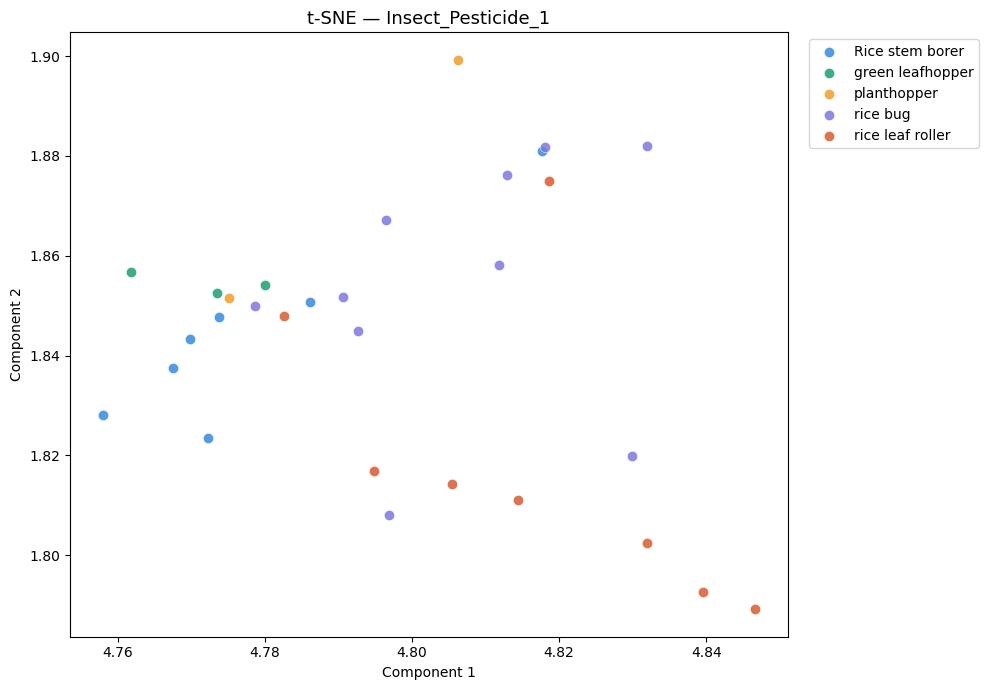

Feature matrix: (428, 512) — running t-SNE...


'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.


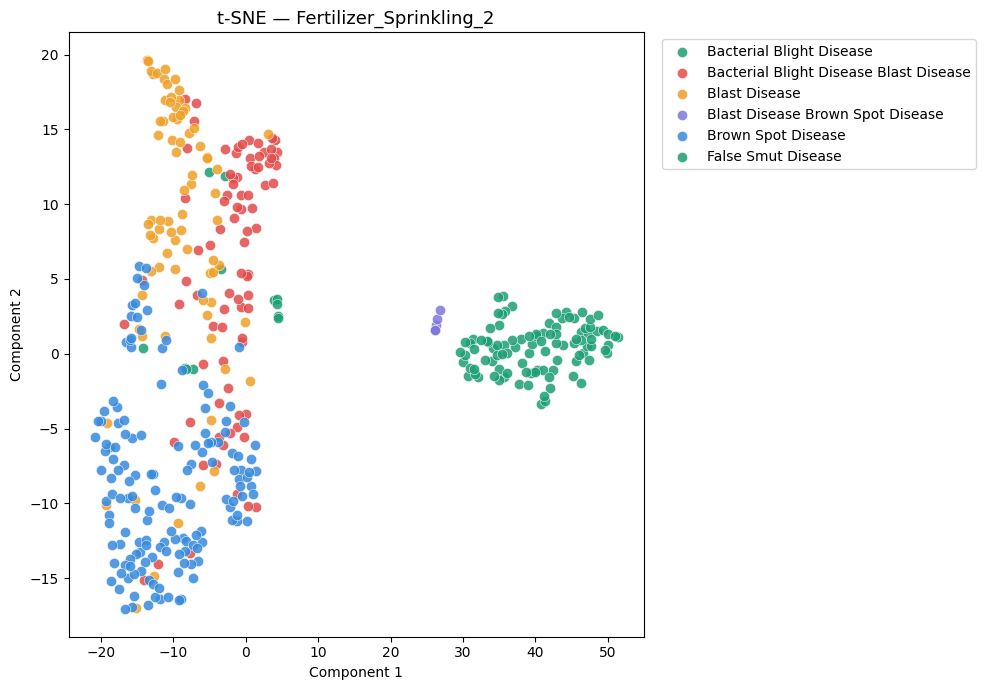

In [ ]:
from sklearn.manifold import TSNE

COLORS_INSECT = ["#378ADD","#1D9E75","#EF9F27","#7F77DD","#D85A30"]
COLORS_FERT   = ["#1D9E75","#E24B4A","#EF9F27","#7F77DD","#378ADD"]

def plot_tsne(model, test_loader, class_names, title, colors):
    extractor = nn.Sequential(*list(model.children())[:-1])
    extractor.eval().to(device)
    feats_list, labs_list = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            f = extractor(images.to(device)).squeeze(-1).squeeze(-1)
            feats_list.append(f.cpu().numpy())
            labs_list.extend(labels.numpy())

    feats      = np.vstack(feats_list)
    labs       = np.array(labs_list)
    perplexity = min(30, len(labs) - 1)
    print(f"Feature matrix: {feats.shape} — running t-SNE...")

    reduced = TSNE(n_components=2, perplexity=perplexity,
                   n_iter=1000, random_state=42,
                   init='pca', learning_rate='auto').fit_transform(feats)

    plt.figure(figsize=(10, 7))
    for i, cls in enumerate(class_names):
        mask = labs == i
        if mask.sum() == 0: continue
        plt.scatter(reduced[mask, 0], reduced[mask, 1],
                    c=[colors[i % len(colors)]], label=cls,
                    alpha=0.85, s=55, edgecolors='white', linewidths=0.4)
    plt.title(f"t-SNE — {title}", fontsize=13)
    plt.xlabel("Component 1"); plt.ylabel("Component 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"/content/{title}_tsne.png", dpi=150)
    plt.show()

plot_tsne(model1, test_loader1, classes1, "Insect_Pesticide_1",     COLORS_INSECT)
plot_tsne(model2, test_loader2, classes2, "Fertilizer_Sprinkling_2", COLORS_FERT)

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Roboflow_ResNet18"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model1.state_dict(), f"{SAVE_DIR}/insect_resnet18.pth")
torch.save(model2.state_dict(), f"{SAVE_DIR}/fertilizer_resnet18.pth")

for fname in ["Insect_Pesticide_1_training.png",
              "Fertilizer_Sprinkling_2_training.png",
              "Insect_Pesticide_1_cm.png",
              "Fertilizer_Sprinkling_2_cm.png",
              "Insect_Pesticide_1_tsne.png",
              "Fertilizer_Sprinkling_2_tsne.png"]:
    src = f"/content/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"{SAVE_DIR}/{fname}")
        print(f"Saved: {fname}")

print("\nAll done — models + plots saved to Google Drive.")

Saved: Insect_Pesticide_1_training.png
Saved: Fertilizer_Sprinkling_2_training.png
Saved: Insect_Pesticide_1_cm.png
Saved: Fertilizer_Sprinkling_2_cm.png
Saved: Insect_Pesticide_1_tsne.png
Saved: Fertilizer_Sprinkling_2_tsne.png

All done — models + plots saved to Google Drive.


In [ ]:
from PIL import Image

def predict(image_path, model, class_names):
    model.eval()
    img    = Image.open(image_path).convert("RGB")
    tensor = transform_eval(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs        = torch.softmax(model(tensor), dim=1)[0]
        top_p, top_i = probs.max(0)
    print(f"\nPrediction : {class_names[top_i.item()]}")
    print(f"Confidence : {top_p.item()*100:.1f}%\n")
    for i, cls in enumerate(class_names):
        bar = "#" * int(probs[i].item() * 30)
        print(f"  {cls:<25} {probs[i].item()*100:5.1f}%  {bar}")

# Usage:
# predict("/content/my_insect_image.jpg",     model1, classes1)
# predict("/content/my_fertilizer_image.jpg", model2, classes2)

In [ ]:
done